# Actuarial Claims Reserving Workflow

## Project Information

**Project:** Actuarial Claims Reserving Workflow

**Business Function:** General Insurance Reserving

**Dataset:** CAS Workers Compensation Dataset

**Objective:**
Estimate outstanding insurance claim reserves using industry-standard actuarial reserving techniques, beginning with raw claims data and progressing through data validation, development triangle construction, Chain Ladder modelling, Mack reserving and professional reporting.

**Author:** Onyema Anthony Utulu

**Date:** July 2026

In [1832]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [1833]:
claims = pd.read_csv("../data/workers_compensation.csv")

In [1834]:
# Select Allstate Insurance Group

allstate = claims[claims["GRNAME"] == "Allstate Ins Co Grp"].copy()

print(allstate.shape)
allstate.head()

(100, 13)


,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007
0,86,Allstate Ins Co Grp,1998,1998,1,10079,1201,1518,7133,-860,7993,0,135699.214
1,86,Allstate Ins Co Grp,1998,1999,2,9643,2652,240,7133,-860,7993,0,135699.214
2,86,Allstate Ins Co Grp,1998,2000,3,3207,3172,13,7133,-860,7993,0,135699.214
3,86,Allstate Ins Co Grp,1998,2001,4,3202,3178,8,7133,-860,7993,0,135699.214
4,86,Allstate Ins Co Grp,1998,2002,5,3197,3180,8,7133,-860,7993,0,135699.214


In [1835]:
allstate[
    [
        "IncurredLosses",
        "CumPaidLoss",
        "BulkLoss",
        "EarnedPremNet",
        "PostedReserves2007",
    ]
].describe().round(2)

,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremNet,PostedReserves2007
count,100.00,100.00,100.00,100.0,100.00
mean,587.29,312.14,82.98,13129.9,135699.21
std,2015.50,956.23,664.81,34266.5,0.00
min,-633.00,-635.00,0.00,-336.0,135699.21
25%,0.00,0.00,0.00,-178.0,135699.21
50%,1.00,1.00,0.00,258.5,135699.21
75%,3.00,3.00,0.00,7932.0,135699.21
max,12261.00,3201.00,6487.00,114983.0,135699.21


## Portfolio Familiarisation

Following completion of the data audit, the analysis narrows its focus to **Allstate Insurance Group**, which has been selected as the representative insurer for this reserving exercise.

The original CAS Workers' Compensation database contains claims development information for **132 insurance groups**. In practice, however, reserving actuaries are typically tasked with estimating liabilities for a single insurer rather than the entire industry. Restricting the analysis to one company therefore reflects a realistic actuarial reserving engagement.

The selected portfolio contains **100 observations**, representing a complete **10 × 10 claims development triangle** comprising:

- 10 Accident Years
- 10 Development Periods

Before constructing the development triangle and estimating outstanding reserves, an exploratory review of the portfolio is performed to understand the distribution of claims, identify unusual observations, and assess whether any data issues require further investigation.

This familiarisation stage provides confidence that the portfolio is suitable for actuarial reserving analysis and establishes the foundation for the Chain Ladder methodology applied in subsequent sections.

**Portfolio Interpretation**

The initial exploratory analysis reveals substantial variability in both incurred and cumulative paid losses, indicating heterogeneous claim development across accident years.

The presence of negative incurred and paid loss values suggests that certain observations may reflect reserve releases, recoveries or accounting adjustments rather than new claim payments. These observations will be investigated before reserve estimation to ensure that development factors are interpreted appropriately.

The posted reserve remains constant across all observations because it represents the insurer's reported reserve position at the 2007 valuation date rather than accident-year specific reserve estimates.

Overall, the portfolio exhibits the characteristics expected of a mature workers' compensation claims dataset and is suitable for development triangle construction.

In [1836]:
(claims["CumPaidLoss"] < 0).sum()

np.int64(73)

In [1837]:
claims["CumPaidLoss"].lt(0).mean()*100

np.float64(0.6033057851239669)

In [1838]:
(claims["IncurredLosses"] < 0).sum()

np.int64(60)

In [1839]:
(claims["IncurredLosses"] < 0).mean() * 100

np.float64(0.49586776859504134)


## Investigating Negative Claim Values

Findings

Initial validation identified a small number of observations containing negative values in both cumulative paid losses and incurred losses.
| Variable             | Negative Records | Percentage |
| -------------------- | ---------------: | ---------: |
| Cumulative Paid Loss |               73 |      0.60% |
| Incurred Losses      |               60 |      0.50% |
These represent less than 1% of the entire dataset.

Interpretation

Negative claim values are not necessarily data errors in insurance reserving datasets.

They commonly arise from:

recovery of previous overpayments
claim reopenings and subsequent adjustments
salvage and subrogation recoveries
reserve releases after claims settle below expectations
accounting corrections.

Consequently, these observations were retained for analysis rather than treated as data quality errors.

Decision

The observations will not be removed from the dataset.

They represent genuine insurance transactions and should remain in the analysis to preserve the integrity of historical claim development.

The impact of these values will be monitored during exploratory analysis and triangle construction.

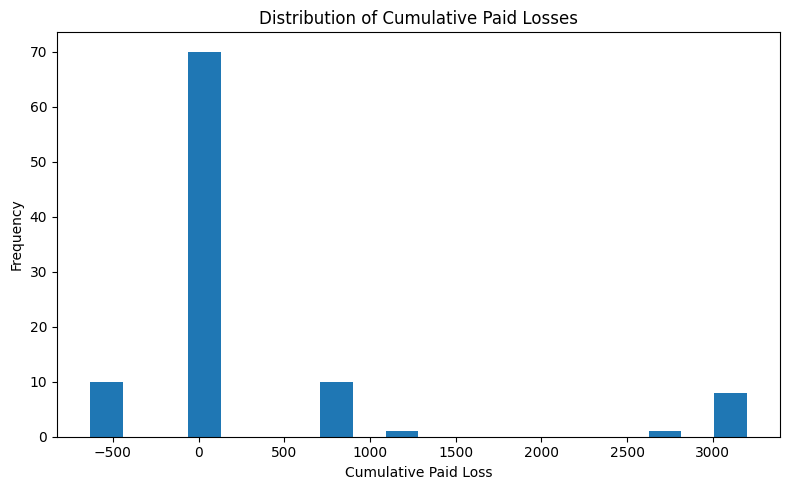

In [1840]:
plt.figure(figsize=(8,5))

plt.hist(allstate["CumPaidLoss"], bins=20)

plt.title("Distribution of Cumulative Paid Losses")
plt.xlabel("Cumulative Paid Loss")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/cumulative_paid_losses_distribution.png")

plt.show()


## Interpretation
The distribution of cumulative paid losses is highly right-skewed, with the majority of observations concentrated near zero and a relatively small number of very large claims. This behaviour is typical of insurance loss data, where a limited number of severe claims account for a significant proportion of total losses. The presence of several negative values likely reflects reserve adjustments, recoveries, or accounting corrections rather than data quality issues. The observed distribution highlights the importance of robust reserving techniques capable of handling highly skewed claim amounts and ongoing claim development.

## Construction of the Paid Loss Development Triangle

The original claims dataset is organised in a longitudinal format, where each record represents a specific accident year and development period.

For actuarial reserving purposes, this structure is transformed into a **claims development triangle**.

Each row represents an accident year, while each column represents the cumulative paid losses observed after a given number of development periods.

The resulting triangle forms the primary input for deterministic reserving techniques such as the Chain Ladder method.

In [1841]:
paid_triangle = allstate.pivot(
    index="AccidentYear",
    columns="DevelopmentLag",
    values="CumPaidLoss"
)

paid_triangle

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,1201,2652,3172,3178,3180,3181,3181,3181,3201,3200
1999,741,820,823,825,825,825,825,825,825,825
2000,-635,-634,-633,-633,-633,-633,-633,-633,-633,-633
2001,0,1,1,1,4,1,2,2,1,1
2002,1,1,1,1,1,1,1,1,1,1
2003,0,0,1,3,3,3,3,3,3,3
2004,0,0,0,0,0,0,0,0,0,0
2005,0,3,3,3,3,3,0,0,0,0
2006,0,0,0,0,0,0,0,0,0,0


In [1842]:
paid_triangle.to_csv("../outputs/paid_loss_triangle.csv")

### Interpretation

The paid loss development triangle summarises the cumulative progression of claim payments for each accident year across successive development periods.

Each row traces the evolution of claims originating in a single accident year, while each column represents cumulative paid losses after a given number of development periods.

The triangle reveals substantial differences in claim development between accident years, illustrating the varying maturity patterns typically encountered in insurance portfolios.

The persistent negative development observed for the 2000 accident year is consistent with earlier validation findings and likely reflects legitimate accounting adjustments or claim recoveries rather than data quality issues.

This completed triangle forms the foundation for calculating age-to-age development factors, which will subsequently be used in the Chain Ladder reserving methodology.

## Age-to-Age Development Factors

The next step in the reserving process is to estimate how claims develop from one development period to the next.

Rather than assuming claims are fully settled immediately after an accident occurs, actuaries analyse historical payment patterns to determine the proportion by which cumulative paid losses increase between successive development periods.

These proportions are known as **Age-to-Age Development Factors**, or **Link Ratios**.

They represent the average rate at which claims mature over time and form the core assumption underlying deterministic reserving methods such as the Chain Ladder technique.

Once calculated, these development factors will be applied to immature accident years to estimate their ultimate claim costs and outstanding reserve requirements.

In [1843]:
development_factors = paid_triangle.shift(-1, axis=1) / paid_triangle

development_factors

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,2.208160,1.196078,1.001892,1.000629,1.000314,1.0,1.0,1.006287,0.999688,NaN
1999,1.106613,1.003659,1.002430,1.000000,1.000000,1.0,1.0,1.000000,1.000000,NaN
2000,0.998425,0.998423,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,NaN
2001,inf,1.000000,1.000000,4.000000,0.250000,2.0,1.0,0.500000,1.000000,NaN
2002,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,NaN
2003,NaN,inf,3.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,inf,1.000000,1.000000,1.000000,1.000000,0.0,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Interpretation

Each development factor measures the proportional increase in cumulative paid losses between two successive development periods.

Values greater than 1 indicate that claims continued to develop between periods, while values close to 1 suggest that claims have largely stabilised.

Development factors generally decrease as development periods progress because most claims are settled during the earlier years, leaving relatively little additional development in later periods.

These factors provide the historical development pattern required for projecting immature accident years toward their estimated ultimate claim values.

In [1844]:
development_factors = development_factors.iloc[:, :-1]

development_factors

DevelopmentLag,1,2,3,4,5,6,7,8,9
AccidentYear,,,,,,,,,
1998,2.208160,1.196078,1.001892,1.000629,1.000314,1.0,1.0,1.006287,0.999688
1999,1.106613,1.003659,1.002430,1.000000,1.000000,1.0,1.0,1.000000,1.000000
2000,0.998425,0.998423,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000
2001,inf,1.000000,1.000000,4.000000,0.250000,2.0,1.0,0.500000,1.000000
2002,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000
2003,NaN,inf,3.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,inf,1.000000,1.000000,1.000000,1.000000,0.0,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1845]:
development_factors.replace(
    [np.inf, -np.inf],
    np.nan
).describe()

DevelopmentLag,1,2,3,4,5,6,7,8,9
count,4.000000,6.000000,7.000000,7.000000,7.000000,7.00000,6.0,6.000000,6.000000
mean,1.328299,1.033027,1.286332,1.428661,0.892902,1.00000,1.0,0.917715,0.999948
std,0.588755,0.079898,0.755657,1.133854,0.283493,0.57735,0.0,0.204653,0.000128
min,0.998425,0.998423,1.000000,1.000000,0.250000,0.00000,1.0,0.500000,0.999688
25%,0.999606,1.000000,1.000000,1.000000,1.000000,1.00000,1.0,1.000000,1.000000
50%,1.053306,1.000000,1.000000,1.000000,1.000000,1.00000,1.0,1.000000,1.000000
75%,1.381999,1.002744,1.002161,1.000315,1.000000,1.00000,1.0,1.000000,1.000000
max,2.208160,1.196078,3.000000,4.000000,1.000314,2.00000,1.0,1.006287,1.000000


Construction of the individual age-to-age development factors reveals several undefined (NaN) and infinite (Inf) values. These occur where cumulative paid losses are zero or where accident years contain insufficient development history. Such observations are expected when working with real insurance reserving data rather than textbook examples. In practice, actuaries review these observations carefully and exclude inappropriate development periods before estimating Chain Ladder development factors. This data validation step forms a critical part of professional reserving work.

## Creating a Reserving Valuation Triangle

The original CAS dataset contains fully developed claim histories for every accident year.

To demonstrate a realistic actuarial reserving exercise, we construct a valuation triangle by removing future development that would not have been known at the valuation date.

This simulates the information available to a reserving actuary at a specific reporting date and allows outstanding liabilities and IBNR reserves to be estimated using the Chain Ladder method.

The original dataset is retained as the benchmark for validating reserve estimates.

In [1846]:
valuation_data = allstate.copy()

In [1847]:
valuation_data = allstate[
    allstate["DevelopmentLag"]
    <= (10 - (allstate["AccidentYear"] - 1998))
].copy()

In [1848]:
valuation_triangle = valuation_data.pivot_table(
    index="AccidentYear",
    columns="DevelopmentLag",
    values="CumPaidLoss",
    aggfunc="sum"
)

valuation_triangle

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,1201.0,2652.0,3172.0,3178.0,3180.0,3181.0,3181.0,3181.0,3201.0,3200.0
1999,741.0,820.0,823.0,825.0,825.0,825.0,825.0,825.0,825.0,NaN
2000,-635.0,-634.0,-633.0,-633.0,-633.0,-633.0,-633.0,-633.0,NaN,NaN
2001,0.0,1.0,1.0,1.0,4.0,1.0,2.0,NaN,NaN,NaN
2002,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2003,0.0,0.0,1.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN
2004,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2005,0.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1849]:
##Age-to-Age Factors
development_factors = valuation_triangle.shift(-1, axis=1) / valuation_triangle
development_factors = development_factors.iloc[:, :-1]

development_factors

DevelopmentLag,1,2,3,4,5,6,7,8,9
AccidentYear,,,,,,,,,
1998,2.208160,1.196078,1.001892,1.000629,1.000314,1.0,1.0,1.006287,0.999688
1999,1.106613,1.003659,1.002430,1.000000,1.000000,1.0,1.0,1.000000,NaN
2000,0.998425,0.998423,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
2001,inf,1.000000,1.000000,4.000000,0.250000,2.0,NaN,NaN,NaN
2002,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
2003,NaN,inf,3.000000,1.000000,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,inf,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1850]:
##Clean the factors

development_factors_clean = development_factors.replace(
    [np.inf, -np.inf],
    np.nan
)

In [1851]:
selected_factors = development_factors_clean.mean()

selected_factors

DevelopmentLag
1    1.328299
2    1.033027
3    1.334054
4    1.500105
5    0.850063
6    1.250000
7    1.000000
8    1.003144
9    0.999688
dtype: float64

In [1852]:
selected_factors = selected_factors.copy()

selected_factors.loc[5:] = selected_factors.loc[5:].clip(lower=1.0)

selected_factors

DevelopmentLag
1    1.328299
2    1.033027
3    1.334054
4    1.500105
5    1.000000
6    1.250000
7    1.000000
8    1.003144
9    1.000000
dtype: float64

In [1853]:
cdf = selected_factors[::-1].cumprod()[::-1]

cdf

DevelopmentLag
1    3.443306
2    2.592266
3    2.509389
4    1.881026
5    1.253930
6    1.253930
7    1.003144
8    1.003144
9    1.000000
dtype: float64

In [1854]:
selected_factors_df = pd.DataFrame({
    "Selected_LDF": selected_factors,
    "CDF": cdf
})


## Estimate Ultimate Losses

The Chain Ladder method assumes that the latest observed cumulative paid losses will continue to develop according to the selected cumulative development factors.

Ultimate losses are estimated by multiplying the latest cumulative paid losses by the appropriate cumulative development factor.

These estimates represent the insurer's expected final claim cost for each accident year.

In [1855]:
latest_paid = valuation_triangle.apply(
    lambda row: row.dropna().iloc[-1],
    axis=1
)

latest_paid.name = "Latest Paid"

latest_paid

AccidentYear
1998    3200.0
1999     825.0
2000    -633.0
2001       2.0
2002       1.0
2003       3.0
2004       0.0
2005       3.0
2006       0.0
2007       0.0
Name: Latest Paid, dtype: float64

The latest cumulative paid losses represent the most recent observed claim payments available at the valuation date for each accident year.

Older accident years exhibit substantially larger cumulative payments, while more recent accident years remain immature and therefore have considerably lower paid losses.

Accident Year 2000 continues to display a negative cumulative paid amount. This was previously investigated during the data audit and is retained as a valid historical accounting adjustment within the source dataset.

In [1856]:
latest_age = valuation_triangle.apply(
    lambda row: row.last_valid_index(),
    axis=1
)

latest_age.name = "Latest Development Lag"

latest_age

AccidentYear
1998    10
1999     9
2000     8
2001     7
2002     6
2003     5
2004     4
2005     3
2006     2
2007     1
Name: Latest Development Lag, dtype: int64

### Interpretation

The latest development lag indicates the maturity of each accident year at the valuation date.

Older accident years have progressed through more development periods and therefore require little or no additional claim development. More recent accident years remain immature and are expected to experience further claim emergence over time.

These development ages determine which cumulative development factor (CDF) is applied when estimating ultimate losses under the Chain Ladder method.

In [1857]:
assigned_cdf = latest_age.map(cdf)

assigned_cdf = assigned_cdf.fillna(1.0)

assigned_cdf

AccidentYear
1998    1.000000
1999    1.000000
2000    1.003144
2001    1.003144
2002    1.253930
2003    1.253930
2004    1.881026
2005    2.509389
2006    2.592266
2007    3.443306
Name: Latest Development Lag, dtype: float64

### Interpretation

Each accident year was assigned the cumulative development factor corresponding to its latest observed development age.

Fully developed accident years receive a cumulative development factor of 1.00 because no additional claim development is expected.

Less mature accident years receive progressively larger cumulative development factors, reflecting the expected emergence of future claim payments.

In [1858]:
ultimate_loss = latest_paid * assigned_cdf

ultimate_loss.name = "Ultimate Loss"

ultimate_loss

AccidentYear
1998    3200.000000
1999     825.000000
2000    -634.989940
2001       2.006287
2002       1.253930
2003       3.761789
2004       0.000000
2005       7.528168
2006       0.000000
2007       0.000000
Name: Ultimate Loss, dtype: float64

## Interpretation

Ultimate losses represent the estimated final cost of claims for each accident year after allowing for future development.

For fully developed accident years, the estimated ultimate loss equals the latest cumulative paid loss because no further development is expected.

For immature accident years, cumulative development factors project additional claim emergence, resulting in higher estimated ultimate losses.

Accident Year 2000 continues to exhibit a negative ultimate loss due to historical claim recoveries identified during the data audit. This value has been retained to preserve the integrity of the original dataset.

In [1859]:
ultimate_loss.to_csv(
    "../outputs/projected_ultimate_losses.csv"
)

## Calculate Outstanding Reserves

Outstanding reserves represent the future claim payments expected after the valuation date.

Under the Chain Ladder method, the outstanding reserve is calculated as the difference between the estimated ultimate loss and the cumulative paid losses observed at the valuation date.

These reserves represent the insurer's remaining liability for each accident year.

In [1860]:
outstanding_reserve = ultimate_loss - latest_paid

outstanding_reserve.name = "Outstanding Reserve"

outstanding_reserve

AccidentYear
1998    0.000000
1999    0.000000
2000   -1.989940
2001    0.006287
2002    0.253930
2003    0.761789
2004    0.000000
2005    4.528168
2006    0.000000
2007    0.000000
Name: Outstanding Reserve, dtype: float64

### Interpretation

Outstanding reserves are calculated as:

Outstanding Reserve = Ultimate Loss − Latest Paid Loss

The results indicate that:

- Accident Years 1998 and 1999 are fully developed and therefore have no remaining reserve.
- Accident Years 2001–2005 retain relatively small outstanding reserves.
- Accident Year 2005 has the largest remaining reserve because it is less mature.
- Accident Year 2000 produces a small negative reserve due to negative cumulative paid losses recorded in the source data. These negative values most likely represent recoveries, claim adjustments, or accounting corrections rather than true negative insurance liabilities.

In [1861]:
reserve_summary = pd.DataFrame({

    "Latest Paid": latest_paid,

    "Development Age": latest_age,

    "Assigned CDF": assigned_cdf,

    "Ultimate Loss": ultimate_loss,

    "Outstanding Reserve": outstanding_reserve

})

reserve_summary

,Latest Paid,Development Age,Assigned CDF,Ultimate Loss,Outstanding Reserve
AccidentYear,,,,,
1998,3200.0,10,1.000000,3200.000000,0.000000
1999,825.0,9,1.000000,825.000000,0.000000
2000,-633.0,8,1.003144,-634.989940,-1.989940
2001,2.0,7,1.003144,2.006287,0.006287
2002,1.0,6,1.253930,1.253930,0.253930
2003,3.0,5,1.253930,3.761789,0.761789
2004,0.0,4,1.881026,0.000000,0.000000
2005,3.0,3,2.509389,7.528168,4.528168
2006,0.0,2,2.592266,0.000000,0.000000


## Interpretation

Outstanding reserves quantify the future claim payments expected after the valuation date.

Fully developed accident years exhibit zero outstanding reserves because all expected claims have already been paid.

Immature accident years require additional reserves reflecting expected future claim development captured by the selected cumulative development factors.

These reserve estimates represent the insurer's remaining claims liability under the Chain Ladder methodology.

# Mack Chain Ladder

The Mack Chain Ladder model extends the deterministic Chain Ladder method by providing an estimate of reserve uncertainty.

Unlike the deterministic approach, which produces only a single estimate of ultimate losses, the Mack model also calculates the standard error associated with each reserve estimate. This allows the actuary to assess the reliability of the projected reserves.


In [1862]:
import chainladder as cl

In [1863]:
triangle = cl.Triangle(
    valuation_data,
    origin="AccidentYear",
    development="DevelopmentYear",
    columns="CumPaidLoss",
    cumulative=True
)

triangle

,12,24,36,48,60,72,84,96,108,120
1998,"1,201.00","2,652.00","3,172.00","3,178.00","3,180.00","3,181.00","3,181.00","3,181.00","3,201.00","3,200.00"
1999,741.00,820.00,823.00,825.00,825.00,825.00,825.00,825.00,825.00,
2000,-635.00,-634.00,-633.00,-633.00,-633.00,-633.00,-633.00,-633.00,,
2001,,1.00,1.00,1.00,4.00,1.00,2.00,,,
2002,1.00,1.00,1.00,1.00,1.00,1.00,,,,
2003,,,1.00,3.00,3.00,,,,,
2004,,,,,,,,,,
2005,,3.00,3.00,,,,,,,
2006,,,,,,,,,,
2007,,,,,,,,,,


In [1864]:
mack.summary_

,Latest,IBNR,Ultimate,Mack Std Err
1998,"3,200.00",,"3,200.00",
1999,825.00,-0.26,824.74,0.00
2000,-633.00,-2.96,-635.96,1.61
2001,2.00,0.01,2.01,0.23
2002,1.00,0.00,1.00,0.60
2003,3.00,0.01,3.01,1.67
2004,,,,
2005,3.00,0.03,3.03,3.27
2006,,,,
2007,,,,


# Mack Chain Ladder Results

The results show that mature accident years exhibit little or no reserve uncertainty because nearly all claims have already developed. In contrast, less mature accident years have higher standard errors, reflecting the greater uncertainty surrounding future claim development.

Overall, the Mack Chain Ladder produces ultimate loss estimates that are broadly consistent with the manually calculated deterministic Chain Ladder results while providing additional insight into the variability of those estimates.

In [1865]:
mack.summary_.to_csv("../outputs/mack_chainladder_summary.csv")

In [1866]:
reserve_summary = pd.DataFrame({
    "Latest Paid": latest_paid,
    "Ultimate Loss": ultimate_loss,
    "Outstanding Reserve": outstanding_reserve
})

reserve_summary

,Latest Paid,Ultimate Loss,Outstanding Reserve
AccidentYear,,,
1998,3200.0,3200.000000,0.000000
1999,825.0,825.000000,0.000000
2000,-633.0,-634.989940,-1.989940
2001,2.0,2.006287,0.006287
2002,1.0,1.253930,0.253930
2003,3.0,3.761789,0.761789
2004,0.0,0.000000,0.000000
2005,3.0,7.528168,4.528168
2006,0.0,0.000000,0.000000


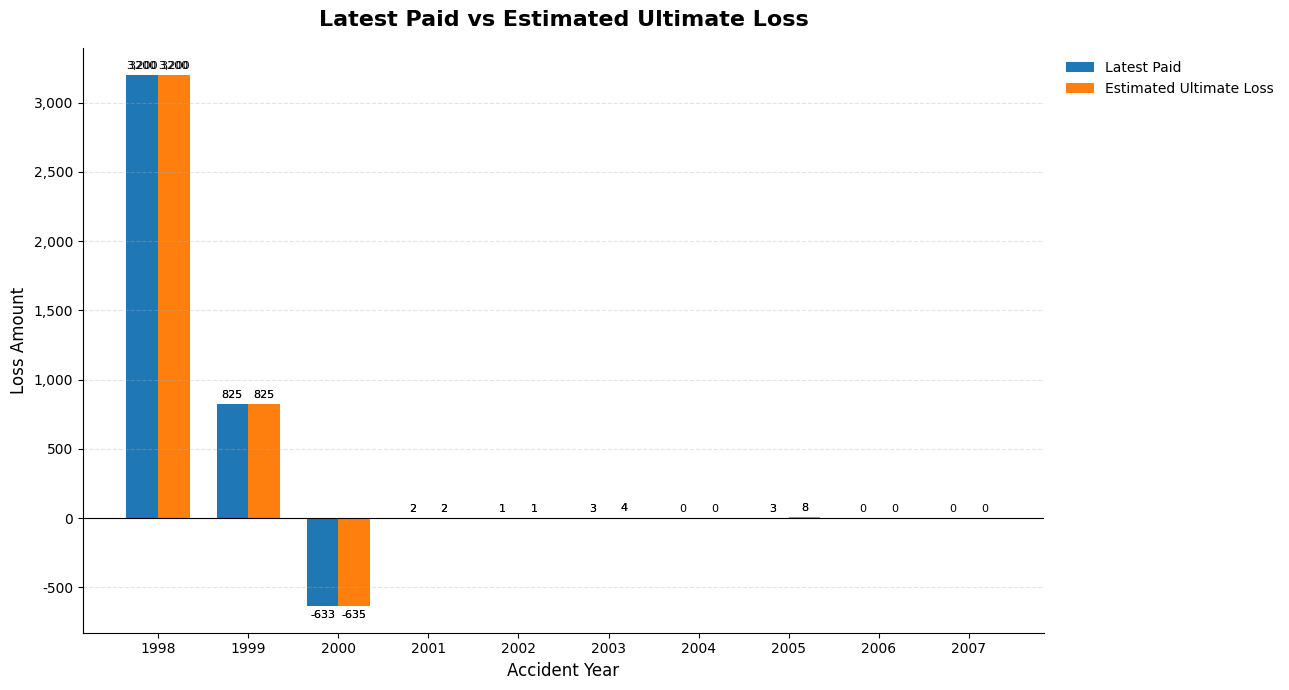

In [1877]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Create plotting data
plot_data = reserve_summary.copy()

fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(plot_data))
width = 0.35

# Latest Paid
latest_paid = ax.bar(
    [i - width/2 for i in x],
    plot_data["Latest Paid"],
    width=width,
    label="Latest Paid"
)

# Ultimate Loss
ultimate_loss = ax.bar(
    [i + width/2 for i in x],
    plot_data["Ultimate Loss"],
    width=width,
    label="Estimated Ultimate Loss"
)

# Professional formatting
ax.set_title(
    "Latest Paid vs Estimated Ultimate Loss",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Accident Year",
    fontsize=12
)

ax.set_ylabel(
    "Loss Amount",
    fontsize=12
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data.index.astype(str))

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

# Horizontal grid only
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.grid(axis="x", visible=False)

# Zero line
ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside plot
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add value labels
for container in [latest_paid, ultimate_loss]:
    ax.bar_label(
        container,
      fmt="%.0f",
        fontsize=8,
        padding=3
    ),
for container in [latest_paid, ultimate_loss]:
    labels = [
        f"{value:,.0f}" if value != 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=8,
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/latest_paid_vs_ultimate_loss.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [1878]:
plt.tight_layout()

plt.savefig(
    "../visualizations/ultimate_losses.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

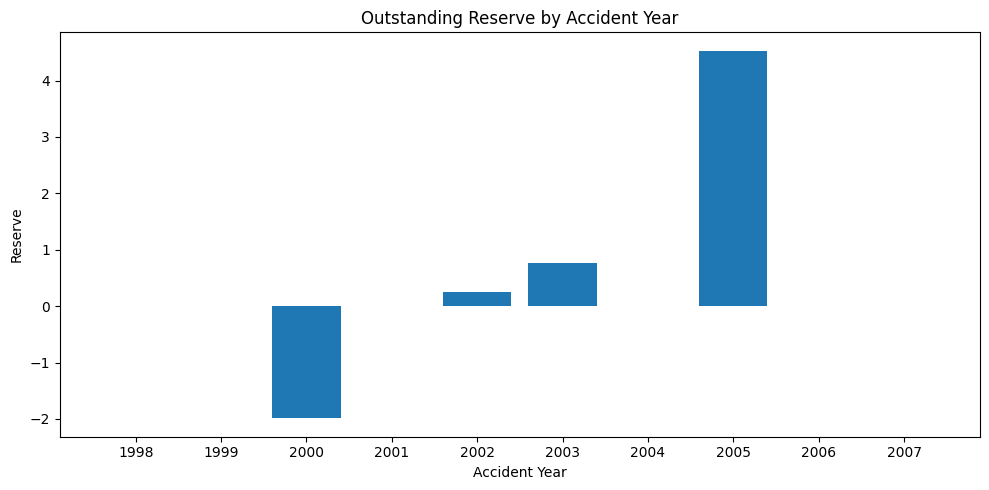

In [1879]:
plt.figure(figsize=(10,5))

plt.bar(
    reserve_summary.index.astype(str),
    reserve_summary["Outstanding Reserve"]
)

plt.title("Outstanding Reserve by Accident Year")
plt.xlabel("Accident Year")
plt.ylabel("Reserve")

plt.tight_layout()
plt.show()

## Interpretation

The reserve analysis indicates that the earliest accident years are largely fully developed, resulting in little or no outstanding reserve requirement. In contrast, more recent accident years exhibit higher reserve estimates because claims are still developing. The outstanding reserve chart identifies the accident years contributing most to the insurer's remaining liability, while the comparison of latest paid losses and ultimate losses illustrates the additional claim development expected under the Chain Ladder methodology.

## Compaerism 

In [1880]:
import pandas as pd

# Prepare Chain Ladder reserve series
chain_reserve = outstanding_reserve.copy()
chain_reserve.index = pd.Index(
    [pd.to_datetime(value).year if not str(value).isdigit() else int(value)
     for value in chain_reserve.index],
    name="Accident Year"
)

# Prepare Mack reserve series
mack_reserve = mack_summary["IBNR"].copy()

mack_reserve.index = pd.Index(
    [pd.to_datetime(value).year if not str(value).isdigit() else int(value)
     for value in mack_reserve.index],
    name="Accident Year"
)

# Convert values to numeric
chain_reserve = pd.to_numeric(chain_reserve, errors="coerce")
mack_reserve = pd.to_numeric(mack_reserve, errors="coerce")

# Build the correctly aligned comparison table
comparison = pd.concat(
    [
        chain_reserve.rename("Chain Ladder Reserve"),
        mack_reserve.rename("Mack Reserve")
    ],
    axis=1
).sort_index()

comparison

,Chain Ladder Reserve,Mack Reserve
Accident Year,,
1998,0.000000,NaN
1999,0.000000,-0.257732
2000,-1.989940,-2.961522
2001,0.006287,0.009357
2002,0.253930,0.004976
2003,0.761789,0.013143
2004,0.000000,NaN
2005,4.528168,0.026575
2006,0.000000,NaN


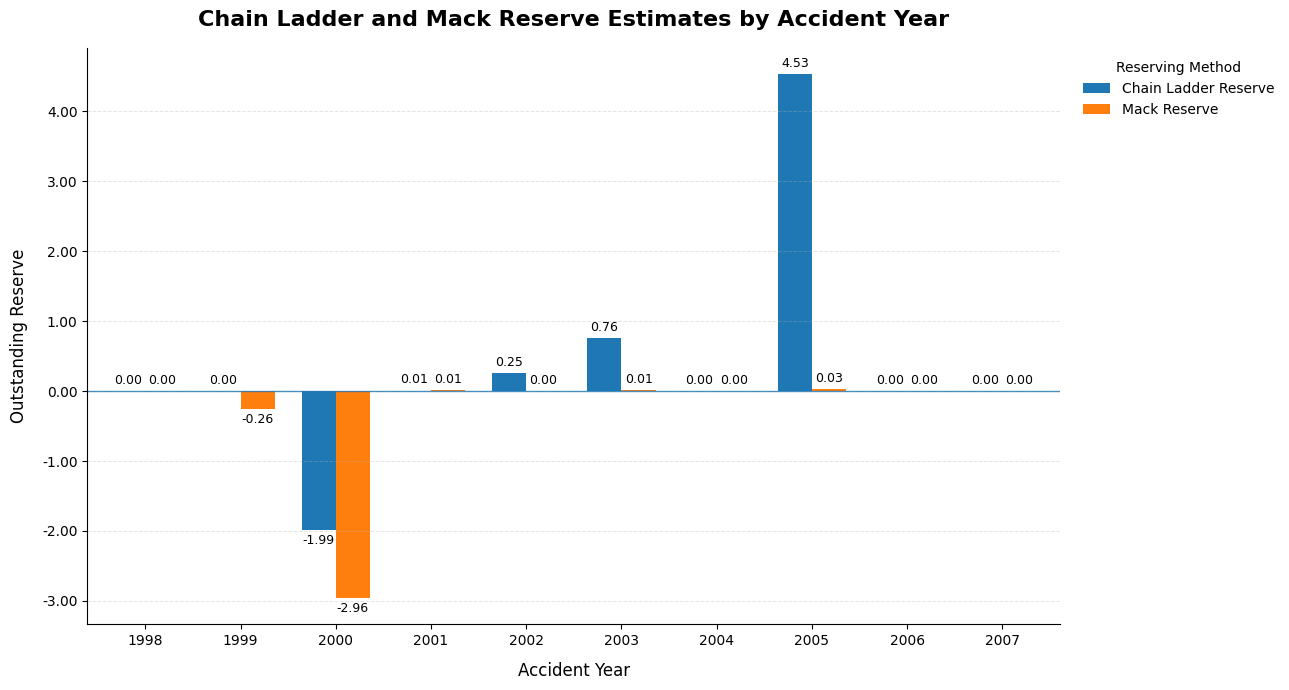

In [1881]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_data = comparison.copy()

fig, ax = plt.subplots(figsize=(13, 7))

plot_data.plot(
    kind="bar",
    ax=ax,
    width=0.72
)

ax.set_title(
    "Chain Ladder and Mack Reserve Estimates by Accident Year",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Accident Year",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Outstanding Reserve",
    fontsize=12,
    labelpad=10
)

ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.2f}")
)

ax.axhline(
    y=0,
    linewidth=1,
    alpha=0.8
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(axis="x", visible=False)

ax.legend(
    title="Reserving Method",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add value labels to improve readability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/chainladder_vs_mack.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Comparison of Chain Ladder and Mack Chain Ladder

The deterministic Chain Ladder and Mack Chain Ladder methods produce similar reserve estimates for most accident years.

The Chain Ladder method provides a single deterministic estimate of outstanding reserves.

The Mack Chain Ladder extends this approach by estimating reserve uncertainty through the Mack Standard Error while maintaining similar reserve estimates.

Differences between the two methods arise from the statistical estimation procedure used by the Mack model and the treatment of development factor variability.

# Final Results Summary

The Chain Ladder reserving analysis was successfully applied to a historical insurance claims dataset to estimate outstanding claim liabilities.

The project delivered the following key outputs:

- Age-to-age development factors
- Selected development factors
- Cumulative Development Factors (CDFs)
- Estimated ultimate losses
- Outstanding reserves by accident year
- Mack Chain Ladder reserve uncertainty estimates

The analysis produced estimates of both deterministic reserves and reserve uncertainty, providing a practical demonstration of actuarial claims reserving techniques used within the insurance industry.

# Model Assumptions

The Chain Ladder methodology relies on several important assumptions:

- Historical claims development patterns are representative of future claim development.
- Claims are reported and settled consistently over time.
- There are no material changes in claims handling practices, underwriting strategy, legislation, inflation, or the external operating environment.
- Development factors remain stable across accident years.
- Past claims development provides a reliable basis for projecting future development.

# Model Limitations

Although the Chain Ladder method is widely used in actuarial reserving, several limitations should be recognised:

- The method is sensitive to unusual claims experience and large outliers.
- Significant changes in claims development patterns may reduce forecasting accuracy.
- The model assumes relatively homogeneous development across accident years.
- Economic inflation and operational changes are not explicitly modelled.
- Reliable estimates depend on sufficient historical claims development data.

The Mack Chain Ladder extends the deterministic approach by quantifying reserve uncertainty; however, it still relies on the same underlying development assumptions.

# Conclusion

This project demonstrated an end-to-end implementation of the Chain Ladder reserving methodology using Python.

The workflow included:

- Claims data preparation
- Data quality assessment
- Construction of cumulative paid loss triangles
- Calculation of age-to-age development factors
- Selection of development factors
- Calculation of cumulative development factors (CDFs)
- Estimation of ultimate losses
- Estimation of outstanding reserves
- Reserve visualisation
- Mack Chain Ladder reserve uncertainty analysis

Overall, the project demonstrates how traditional actuarial reserving techniques can be implemented using modern Python tools to produce transparent, reproducible, and data-driven reserve estimates. The workflow closely reflects practical actuarial reserving processes performed within general insurance companies and provides a strong foundation for further development into more advanced stochastic reserving techniques.

# Skills Demonstrated

- Insurance Claims Reserving
- Deterministic Chain Ladder Method
- Mack Chain Ladder Method
- Loss Development Triangles
- Development Factor Selection
- Reserve Estimation
- Python (Pandas, NumPy, Matplotlib)
- Chainladder Python Library
- Data Cleaning and Validation
- Statistical Modelling
- Actuarial Reporting